### Implementing simple Chatbot Using LangGraph

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [4]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")
llm.invoke("Hello")

AIMessage(content='<think>\nOkay, the user said "Hello". I should respond in a friendly and open way. Let me make sure to acknowledge their greeting and invite them to ask questions or share what\'s on their mind. Keep it simple and welcoming.\n\nI need to check if there are any specific guidelines I should follow here. The response should be in the same language as the user\'s message, which is English. Also, avoid using markdown and keep it natural. Alright, let\'s go with a warm greeting and an offer to help.\n</think>\n\nHello! How can I assist you today? Feel free to ask any questions or share what\'s on your mind. 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 134, 'prompt_tokens': 9, 'total_tokens': 143, 'completion_time': 0.262467184, 'prompt_time': 0.000211196, 'queue_time': 0.046792703, 'total_time': 0.26267838}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logp

In [5]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hey I am Anil Kanaparthi and i like to play cricket")

AIMessage(content="<think>\nOkay, the user is Anil Kanaparthi and he enjoys playing cricket. Let me see how to respond appropriately.\n\nFirst, I should acknowledge his introduction and express interest in cricket. Maybe ask about his favorite team or how long he's been playing to keep the conversation going.\n\nI should check if there's any specific aspect of cricket he's interested in, like batting, bowling, or fielding. Also, maybe mention current cricket events or tournaments if relevant.\n\nNeed to keep the tone friendly and open-ended to encourage him to share more. Avoid making assumptions beyond what he's provided.\n\nMake sure the response is concise and not too long. Use proper grammar and friendly language.\n</think>\n\nHi Anil! Nice to meet you. 🏏 Cricket is such an exciting sport—do you have a favorite team or player you follow? Are you more into batting, bowling, or fielding? Let me know if you'd like to share more about your cricket experiences!", additional_kwargs={}, r

### We Will start With Creating Nodes

In [6]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

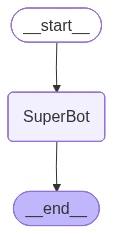

In [7]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Anil Kanaparthi And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Anil Kanaparthi And I like cricket', additional_kwargs={}, response_metadata={}, id='94c3a354-a0c5-453a-b8b6-9d89ba4c33fd'),
  AIMessage(content="<think>\nOkay, the user introduced themselves as Anil Kanaparthi and mentioned they like cricket. I should respond by acknowledging their name and showing interest in their cricket connection. Since cricket is popular in many countries, maybe they want to discuss the sport, favorite teams, or recent matches. I can ask about their favorite aspects of cricket, their favorite teams, or if they play the game themselves. I should keep the tone friendly and open to encourage conversation. Also, make sure to use proper grammar and structure the response clearly. Let me check if there's anything else needed. No, just a simple, engaging reply should work here.\n</think>\n\nHello Anil! Nice to meet you. 🏏 Cricket is an amazing sport—there's so much to love about it, whether it's the strategy, the thrill

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.



#### Streaming The Responses With Stream Method

In [9]:
# Create a thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"I am living in Hyd"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='<think>\nOkay, let\'s see. The user mentioned they\'re living in Hyderabad, also known as Hyd. I need to figure out what they might need help with. Hyderabad is a big city in India, known for its IT industry, historical sites like the Charminar, and a lot of cultural heritage. \n\nFirst, maybe they need information about local attractions. They could be a tourist or a resident looking for things to do. I should list some popular spots like the Charminar, Golconda Fort, and Hussain Sagar Lake. Also, mentioning local markets like Laad Bazaar for shopping might be useful.\n\nTransportation in Hyderabad is another aspect. They have the Hyderabad Metro, which is quite extensive now, and the Outer Ring Road (ORR) is a major highway. Maybe they need tips on getting around using public transport or taxis.\n\nCuisine is a big part of Hyderabad. Biryani and haleem are famous dishes. I can suggest trying local restaurants like Bawarchi or Paradise, an

In [10]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='I am living in Hyd', additional_kwargs={}, response_metadata={}, id='d0884459-8bf9-465b-9176-6c209fb30077'), AIMessage(content='<think>\nOkay, let\'s see. The user mentioned they\'re living in Hyderabad, also known as Hyd. I need to figure out what they might need help with. Hyderabad is a big city in India, known for its IT industry, historical sites like the Charminar, and a lot of cultural heritage. \n\nFirst, maybe they need information about local attractions. They could be a tourist or a resident looking for things to do. I should list some popular spots like the Charminar, Golconda Fort, and Hussain Sagar Lake. Also, mentioning local markets like Laad Bazaar for shopping might be useful.\n\nTransportation in Hyderabad is another aspect. They have the Hyderabad Metro, which is quite extensive now, and the Outer Ring Road (ORR) is a major highway. Maybe they need tips on getting around using public transport or taxis.\n\nCuisine is a big part of

In [12]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='<think>\nOkay, so the user mentioned they like football again. Let me check the history. The first time they said they like football, I asked about their favorite team or league and what they enjoy most. Now they\'ve said "I also like football" again. Hmm, maybe they just wanted to reiterate their interest or perhaps there\'s a typo. Since they already expressed their interest in football once, maybe they\'re emphasizing it. I need to respond in a way that\'s engaging but not redundant.\n\nWait, maybe they\'re trying to add more information but didn\'t finish. Let me see the previous messages. They first said they like cricket, then football. Now they repeated "I also like football." Maybe they want to expand on that. I should acknowledge their repetition and invite them to share more details. Let me make sure my response is friendly and encouraging. Perhaps ask if they have a favorite team or player in football now. Also, check if they fol

In [13]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Anil Kanaparthi And I like cricket', additional_kwargs={}, response_metadata={}, id='3bab024f-f80e-454b-9fbb-317919b6dbdf'), AIMessage(content="<think>\nOkay, the user introduced himself as Anil Kanaparthi and mentioned he likes cricket. I should respond in a friendly and welcoming manner. Since he mentioned liking cricket, it's good to acknowledge that and maybe ask a follow-up question to keep the conversation going. Let me make sure the reply is positive and engaging. Also, I need to keep it concise and natural, avoiding any markdown formatting. Just a simple greeting, a comment on his interest in cricket, and an open-ended question to encourage further interaction. Let me check for any typos or errors. Alright, that should work.\n</think>\n\nHello Anil! Nice to meet you. Cricket is an awesome sport—I hope you're enjoying the matches! Do you follow any particular team or player? 😊", additional_kwargs={}, response_metadata={'token_usa

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [ ]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Anil Kanaparthi and I like to play cricket"]},config,version="v1"):
    print(event)

{'event': 'on_chain_start', 'run_id': '278f8f7c-a813-4c9d-887a-681af6b6e755', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '3'}, 'data': {'input': {'messages': ['Hi My name is Anil Kanaparthi and I like to play cricket']}}, 'parent_ids': []}
{'event': 'on_chain_start', 'name': 'SuperBot', 'run_id': '2b72cfcd-5faa-4ca9-8df1-dff8a9637aef', 'tags': ['graph:step:4'], 'metadata': {'thread_id': '3', 'langgraph_step': 4, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:3ee6ffc3-11f0-90fa-7368-a3242e99d907'}, 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Anil Kanaparthi and I like to play cricket', additional_kwargs={}, response_metadata={}, id='ed259fbb-2733-4aba-8172-e3988a9d7cfa'), AIMessage(content="<think>\nOkay, the user introduced themselves as Anil Kanaparthi and mentioned they like to play cricket. I need to respond warmly. Let me start 

: 